In [23]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns #import seaborn library
import matplotlib.pyplot as plt #import matplotlib.pyplot library

In [24]:
ride_reliability = pd.read_csv("../../data/raw-data/MBTA_The_RIDE_Reliability.csv")

#convert csv file into a dataframe
ride_reliability_df = pd.DataFrame(ride_reliability)

#print the first 10 rows of dataframe
print(ride_reliability_df.head(10))

#print shape of dataframe
print(ride_reliability_df.shape)

                trip_date  ontime_trip_count  trip_count  ObjectId
0  2014/07/01 04:00:00+00               5479        5884         1
1  2014/07/02 04:00:00+00               5297        5612         2
2  2014/07/03 04:00:00+00               4959        5306         3
3  2014/07/04 04:00:00+00               1530        1558         4
4  2014/07/05 04:00:00+00               2420        2580         5
5  2014/07/06 04:00:00+00               2202        2369         6
6  2014/07/07 04:00:00+00               5048        5332         7
7  2014/07/08 04:00:00+00               5492        5925         8
8  2014/07/09 04:00:00+00               5668        6163         9
9  2014/07/10 04:00:00+00               5487        6027        10
(3681, 4)


In [26]:
#find na values in the columns
ride_reliability_df_na = ride_reliability_df.isna().sum()
print(ride_reliability_df_na) #no NA values in the dataframe


trip_date            0
ontime_trip_count    0
trip_count           0
ObjectId             0
dtype: int64


In [27]:
print(type(ride_reliability_df))
print(ride_reliability_df["trip_date"].dtypes)
print(ride_reliability_df["ontime_trip_count"].dtypes)
print(ride_reliability_df["trip_count"].dtypes)
print(ride_reliability_df["ObjectId"].dtypes)


#convert the "trip_date" column to string data type to prepare for splitting
ride_reliability_df["trip_date"] = ride_reliability_df["trip_date"].astype(str)

print("After converting to string type: ", ride_reliability_df["trip_date"].dtypes)

<class 'pandas.core.frame.DataFrame'>
object
int64
int64
int64
After converting to string type:  object


In [28]:
#split the "trip_date" column based on space to separate date and time
ride_reliability_df[["Date", "Time"]] = ride_reliability_df["trip_date"].str.split(" ", expand = True)
print(ride_reliability_df.head())

#convert "Date" column to YYYY-MM-DD date format to match the column in the cleaned Clean_Ride_Accuracy.csv file
ride_reliability_df["Date"] = pd.to_datetime(ride_reliability_df["Date"]) #convert "Date" column to dateime format

ride_reliability_df["Date"] = ride_reliability_df["Date"].dt.strftime('%Y-%m-%d') #reformat "Date" value as yyyy-mm-dd

print(ride_reliability_df["Date"].head()) #print first few rows of reformatted Date column


                trip_date  ontime_trip_count  trip_count  ObjectId  \
0  2014/07/01 04:00:00+00               5479        5884         1   
1  2014/07/02 04:00:00+00               5297        5612         2   
2  2014/07/03 04:00:00+00               4959        5306         3   
3  2014/07/04 04:00:00+00               1530        1558         4   
4  2014/07/05 04:00:00+00               2420        2580         5   

         Date         Time  
0  2014/07/01  04:00:00+00  
1  2014/07/02  04:00:00+00  
2  2014/07/03  04:00:00+00  
3  2014/07/04  04:00:00+00  
4  2014/07/05  04:00:00+00  
0    2014-07-01
1    2014-07-02
2    2014-07-03
3    2014-07-04
4    2014-07-05
Name: Date, dtype: object


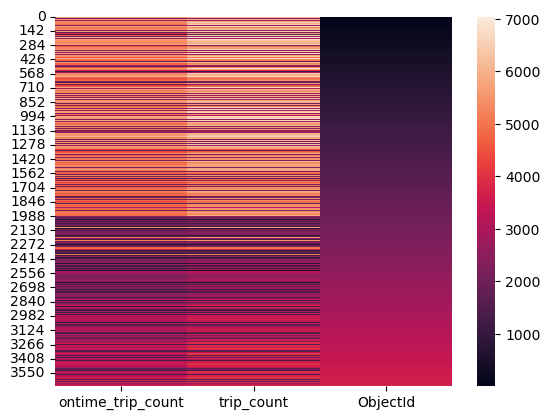

In [31]:
#subset dataframe to create a heatmap to visualize missing data - even though there are no missing data. Keep numeric value columns
ride_reliability_df_subset = ride_reliability_df[[ "ontime_trip_count", "trip_count", "ObjectId"]]

#create heatmap of dataframe, no NA values, no NA values needed to drop
sns.heatmap(ride_reliability_df_subset)
plt.show() #show heatmap

       ontime_trip_count   trip_count     ObjectId
count        3681.000000  3681.000000  3681.000000
mean         3349.814453  3730.092910  1841.000000
std          1541.218043  1759.167967  1062.757498
min           150.000000   163.000000     1.000000
25%          2190.000000  2353.000000   921.000000
50%          3005.000000  3362.000000  1841.000000
75%          4943.000000  5529.000000  2761.000000
max          6181.000000  7045.000000  3681.000000


<Axes: >

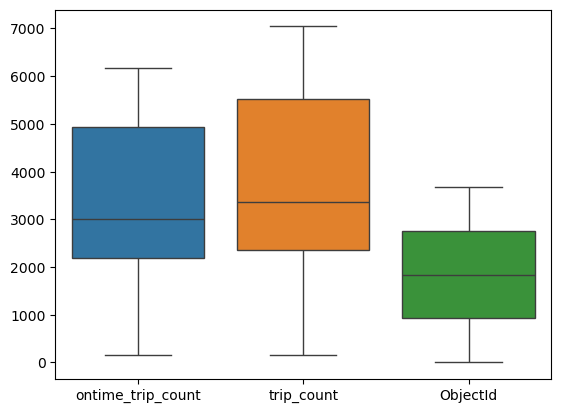

In [32]:
#find outliers using describe()
print(ride_reliability_df.describe())

#create boxplot of dataframe to visualize outliers
sns.boxplot(data=ride_reliability_df)

In [22]:
#export clean csv file to processed-data folder
ride_reliability_df.to_csv("../../data/processed-data/Clean_Ride_Reliability.csv")